In [1]:
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.load_tex_defs()

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

ModuleNotFoundError: No module named 'bayesian_stats_course_tools'

To create your own package, have a look at the example in `course_tools` and the documentation at https://packaging.python.org/en/latest/tutorials/packaging-projects/.

The key files are
- The `pyproject.toml` file, which specifies that this is a python package
- The `src/bayesian_stats_course_tools/__init__.py`, which makes `bayesian_stats_course_tools` a python module that can be imported.

### Exercise

1. Create a new directory at the top of the JupyterLab file system
2. Create a new Python notebook

3. Obtain an estimate of the value of $\pi$
    - From the definition in `numpy`
    - Using an analytic series expansion: $\pi = 4 \sum_{k=0}^\infty \frac{(-1)^{k}}{2k + 1}$
    - Using a Monte-Carlo estimate: 
        1. Sample $n$ points uniformly on the unit square using `numpy.random.uniform`
        2. Count the number $n_{<r}$ of points with distance $r = \sqrt{x^2+y^2} \leq 1$
        3. Compare the fraction $\frac{n_{<r}}{n}$ to the ratio of the area of a quadrant of a disc to the area of the square to derive an estimate of $\pi$
    - Bonus: Repeat for (hyper) cube and (hyper) ball in 3 or more dimensions. How does the number of samples required to get a robust estimate of $\pi$ change with the number of dimensions? 

4. Use the debugger to step through some iterations of your code.

5. Create plots showing the estimated value as the number of terms in the series expansion and the number of Monte-Carlo samples is varied

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [3]:
# 3.1

print(np.pi)

3.141592653589793


In [33]:
# 3.2

def pi_series(n):
    pi = 0
    for i in range(n):
        pi += ((-1)**i)/(2*i+1)
    return 4*pi

print(pi_series(1000))

3.140592653839794


In [34]:
# 3.3

n = 1000

def pi_mc(n):
    point_x = np.random.uniform(0,1, n)
    point_y = np.random.uniform(0,1, n) 
    
    radii = (point_x**2 + point_y**2)**(1/2)
    n_r = (radii <= 1).sum()
    
    pi_mc = 4*(n_r/len(point_x))
    
    return pi_mc

print(pi_mc(n))

3.144


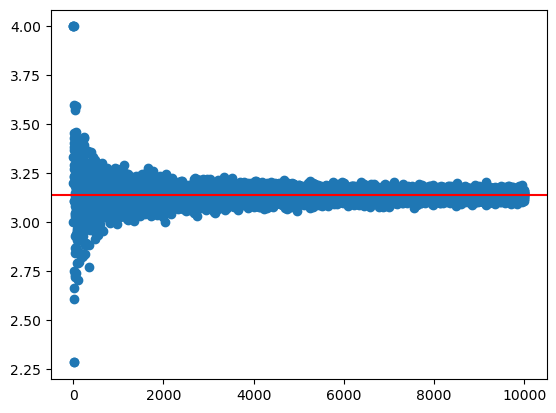

In [36]:
# switch between pi_mc() and pi_series()

n = 10000
piis = []

for i in range(n):
    i += 1
    piis.append(pi_mc(i))

x = np.linspace(1, n, n)
plt.scatter(x, piis)
plt.axhline(np.pi, color = "red")

plt.show()